**Name:** Alex Medina

**Course:** AST 5765

**Quiz Date:** 29 September 2025

In [3]:
# General Imports

import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

### PART 1: READING FIT FILES

Filename: pix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      71   (512, 512)   int16   


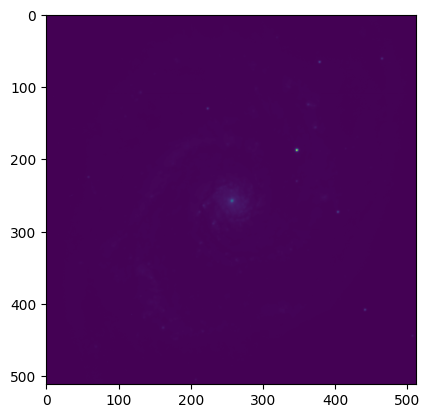

In [4]:
# Get a FITS file and show info about the file
fits.info('pix.fits') 

# To read image data from file
image = fits.getdata('pix.fits')

# To display the image

plt.imshow(image)

### PART 2: NOTES ON MEASUREMENTS

**Fundamental Quantity:** physical quantity that can't be described in terms of other quantities.

*Examples:* length, time, mass

**Derived Quantity:** A quantity obtained from fundamental quantities.

*Examples:* speed, acceleration, pressure

**Accuracy:** How close you are to the actual measurement.

**Precision:** How close your measurements are to each other.

Generally, you want a mix of precision and accuracy.

### PART 3: ON ERROR

**Illegitimate error:** Errors from doing something fundamentally wrong in your method, math, or assumptions.
     - These shouldn't happen if you check your work carefully.

*Examples:* Typo in code where you mix SI and cgs units.

**Systematic error:** A consistent offset between the measured value and the true value.
     - Predictable, but can ruin accuracy if not corrected. You need to find and remove it.

*Examples:* A scale that reads 2kg above the true weight, or removing background effects.
        
**Random error:** Unpredictable variations between measurements.
     - Called "noise." Can’t remove completely, but you can reduce it by repeating measurements and averaging.

*Examples:* Small fluctuations in measuring star brightness, or human reaction time when starting/stopping a stopwatch.

**Absolue error:** ∣Measured Value−True Value∣

**Relative error:** ∣Measured Value−True Value∣ / True Value

Absolute error good for when the size of the error itself matters, like when using a ruler. Relative error is when you want to know how big the error is compared to the measurement itself.

### PART 4: BASIC STATISTICS

Mean of data $\bar x$: 

$$ \bar x = \frac{1}{N} \sum x_{i}$$

Median of data ( mid point of data points ) $\mu_{1/2} $:

$$ P( x_i < \mu_{1/2} ) = P( x_i > \mu_{1/2} ) = 0.5  $$

Standard deviation, $\sigma = \sqrt{\mathrm{var}(x_i)}$


$$ \sigma^{2} = \frac{1}{N-1}\sum (x_{i}-\bar x)^{2}$$

or 

$$\sigma^{2} = \frac{1}{N-m}\sum (x_{i}-\bar x)^{2}$$

If you already know the true mean of the population, you divide by N. But usually, we don’t know the true mean — we estimate it from the same data. Once you use the data to calculate the sample mean you “spend” 1 piece of information so 1 degree of freedom lost. This corrects the bias in variance estimation.

The single m is a more general case where m = the number of parameters you estimated from the data. Each estimated parameter reduces the degrees of freedom.

In [5]:
# Example

# Data set
data_set = np.array( [0.2, 2.0, 0.3, 1.4, 0.27, 0.45, 1.35, 0.5, 0.8, 1.1, 1.35, 0.3] )

# Calculate mean
data_mean = np.mean(data_set)
print('The mean is:', data_mean)

# Calculate standard deviation:
data_sig1 = np.std(data_set, ddof=1)

# More formulaic
data_sig2 = 0
for i in range(len(data_set)):
    data_sig2  += (data_set[i] - data_mean)**2
data_sig2  = np.sqrt((1/( len(data_set) - 1)) * data_sig2)

print('The sigma is:', data_sig1, data_sig2)

The mean is: 0.8350000000000001
The sigma is: 0.5903542850002715 0.5903542850002715


Sometimes it is more meaningful to use the median over the mean, such as when your data is skewed left or skewed right, so the median is closer to the true mean.

PART 5: PROBABILITY

A **probability density function (PDF)** describes how probability is distributed over possible values of a random variable.

For a continuous random variable $X$ with PDF $f(x)$:

$$ f(x) \geq 0$$

Total probability = 1:

$$ \int_{-\infty}^{\infty} f(x) dx = 1 $$


Probability of $X$ in interval $[a,b]$:

$$ P(a \leq X \leq b) = \int_{a}^{b} f(x) dx $$


For a discrete random variable $X$ with probability mass function (PMF) $p(x)$:

$$ p(x) \geq 0$$

Total probability = 1:

$$ \sum_x p(x) = 1 $$

Probability at a point:

$$ P(X = x_i) = p(x_i) $$

| Feature                  | Discrete                               | Continuous                                     |
|---------------------------|----------------------------------------|-----------------------------------------------|
| Values                   | Countable (e.g. dice rolls, coin flips)| Any real number (e.g. time, height, temperature) |
| Function                 | PMF $p(x)$                             | PDF $f(x)$                                    |
| Single Point Probability | $P(X=x) > 0$ possible                  | $P(X=x) = 0$, only intervals matter           |
| Probability Rule         | $\sum p(x) = 1$                        | $\int f(x)\, dx = 1$                          |

### PART 6: POISSON AND GAUSSIAN DISTRIBUTIONS

**Poisson distribution:** Gives the probability of observing $x$ events in a fixed time (or space) interval, out of n possible events, each has p probability of happening, **when events happen randomly and independently**.

*Key assumptions:*  
- The number of possible events $n \gg 1$ (often unknown).  
- The probability $p$ of a single event is small (also usually unknown).  
- What we really use is the **average number of events** in the interval: $N$.

$$ P(x;N) = \frac{N^{x}}{x!} e^{-N} $$

- $x =$ observed number of events  
- $N =$ expected (average) number of events  over a time interval

Normalization:

$$ \Sigma_{x=0}^{\infty} P(x;N) = 1 $$

Mean (average value):

$$ \bar{x} = N $$

Variance:

$$ \sigma^2 = N \quad \Rightarrow \quad \sigma = \sqrt{N} $$

*Key ideas:*
- The Poisson distribution is a **discrete probability distribution**.  
- It describes **statistical fluctuations** when counting events in finite time/space windows.  
- **Example:** Counting photons from a star — light measurements follow Poisson statistics.  
- If uncertainties are random (not systematic), they often follow Poisson behavior.  

**Gaussian distribution:** The limiting case of Poisson as N gets large.

$$ p(x) = \frac{1}{\sigma \sqrt 2\pi} \mathrm{exp}[-\frac{1}{2} (\frac{x-\mu}{\sigma})^2]$$

*Key points:*
- ...but there is no probability between the points.  They just follow a Gaussian-ish envelope.
- For large $N$, Poisson approaches a Gaussian with  $\bar x = N$ and $\sigma = \sqrt{N}$
- It's not just any Gaussian. The mean and standard deviation are locked together!
- On the plots below, compare how the approximation improves:

### PART 7: ERRORS

To look at measurement uncertainty, we often take sample measurements and use $\sigma$.

**Error propagation:** If you calculate a new quantity from measured values, the uncertainties in those measurements “propagate” into the final result.

**General Error Propagation Formula:**

When a result $f$ depends on measured quantities $u, v, \dots$, the uncertainties in those inputs propagate into the uncertainty in $f$.

$$
\sigma_f^2 \simeq 
  \sigma_u^2 \left(\frac{\partial f}{\partial u}\right)^2
+ \sigma_v^2 \left(\frac{\partial f}{\partial v}\right)^2
+ \dots
+ 2\sigma_{uv}^2 \frac{\partial f}{\partial u}\frac{\partial f}{\partial v}
+ \dots
$$

- $\sigma_u^2, \sigma_v^2$ = variances of input variables  
- $\sigma_{uv}^2$ = covariance term (captures correlation between $u$ and $v$)  

If inputs are independent (uncorrelated), covariance terms vanish:

$$
\sigma_f^2 \simeq 
  \sigma_u^2 \left(\frac{\partial f}{\partial u}\right)^2
+ \sigma_v^2 \left(\frac{\partial f}{\partial v}\right)^2
+ \dots
$$

- Lets us **compute the error in a derived quantity** $f(u,v,...)$  
- Shows which variables contribute most to $\sigma_f$  
- Helps decide which measurements need the highest precision

**Example 1:** Suppose we have the equation:

$$ z = 3x + y^2 $$

Where

$$ x = 2.0 \pm 0.2 $$

$$ y = 1.32 \pm 0.15 $$

What is z + dz? (note that the term after the $\pm$ is the dx or dy, which we consider the UNCERTAINTY or $\sigma$.)

In [6]:
# Variables and dx

x, dx = 2.0, 0.2
y, dy = 1.32, 0.15

# Equation
z = 3*x + y**2

# Partial derivative w.r.t first variable
par1 = 3.0

# Partial derivative w.r.t second variable
par2 = 2.0 *y

# To find the error probagation

dz = np.sqrt( (par1 * dx)**2 + (par2 * dy)**2 )

print('z +- dz = {0:.2f}+-{1:.2f}'.format(z, dz))

z +- dz = 7.74+-0.72


**Example 2:** In an experiment to count particles emitted by a decaying radioactive source, we measure:

$$ N1 = 723 $$

$$ N2 = 19 $$

In a spand of 15 seconds. The events are random and obey Poisson stats. Assume that we have made a very careful measurement of the background counting rate in the absence of the radioactive source and obtained a value B = 14.2 counts with negligible error for the same time interval. 
- What is the uncertainty in our measurement N1? What is it for N2?
- If the relative uncertainty is $\frac{\sigma_x}{x}$, with x the corrected number of counts (corrected for the background), what is the relative uncertainties of N1 and N2?

In [7]:
# After correcting

N1 = 723
N2 = 19

x = 14.2

N1_c = 723 - x
N2_c = 19 - x

# Recall that if it follows Poisson distributions, we get
# sigma = root(N)

sigN1   = np.sqrt(N1)
sigN2   = np.sqrt(N2)

# Or it could go something like

rel_uncertaintyN1, rel_uncertaintyN2 = sigN1 / x, sigN2 / x

print('Relative uncertainties:', rel_uncertaintyN1, rel_uncertaintyN2)

Relative uncertainties: 1.8935675577110918 0.3069647143338503


**Example 3:** Major Tom is travelling through the Solar system and is lost! The only clues he has at to where he is, is a pendulum he has with him with length $L = 2.00\pm 0.01$m, a stopwatch and a chart of the gravities of bodies in the Solar system: 

Celestial Body | Gravitational Acceleration (m/s²) |
|----------------|-----------------------------------|
| Earth          | 9.807                             |
| Moon           | 1.62                              |
| Mars           | 3.71                              |
| Venus          | 8.87                              |
| Mercury        | 3.7                               |
| Ceres          | 0.27                              |
|

He takes the following measurements for the period of the pendulum:

In [8]:
# Measured times
t_meas = np. array([4.55, 4.62, 4.51, 4.71, 4.69, 4.58, 4.65, 4.63, 4.52, 4.64,
                    4.66, 4.68, 4.58, 4.54, 4.71, 4.68, 4.67, 4.52, 4.61, 4.63])

# Remember, if its just N, then sigma is root(N)
# But if its a data set, then the sigma or error dt is the standard deviation using np.std
dt = np.std(t_meas,ddof=1)

# We know the length and length uncertainty
L, dL = 2.00, 0.01

# Period T  = 2 * pi * root( L / g)
# So to solve for g
# g = L / ( t_meas / (2 * np.pi) )**2
# Equation
g = (L * 4 * np.pi**2) / t_meas**2

# Partials
par1 = -2 * (L * 4 * np.pi**2) / t_meas**3

par2 = (4 * np.pi**2) / t_meas**2

# Uncertainty in gravity
dg = np.sqrt( (par1 * dt)**2 + (par2 *dL)**2 )

#print(g)
#print(dg)

for i in np.arange(len(g)):
    print('Gravity measurements: {0:.2f} +- {1:.2f}'.format(g[i], dg[i]))

Gravity measurements: 3.81 +- 0.11
Gravity measurements: 3.70 +- 0.11
Gravity measurements: 3.88 +- 0.11
Gravity measurements: 3.56 +- 0.10
Gravity measurements: 3.59 +- 0.10
Gravity measurements: 3.76 +- 0.11
Gravity measurements: 3.65 +- 0.10
Gravity measurements: 3.68 +- 0.11
Gravity measurements: 3.86 +- 0.11
Gravity measurements: 3.67 +- 0.10
Gravity measurements: 3.64 +- 0.10
Gravity measurements: 3.60 +- 0.10
Gravity measurements: 3.76 +- 0.11
Gravity measurements: 3.83 +- 0.11
Gravity measurements: 3.56 +- 0.10
Gravity measurements: 3.60 +- 0.10
Gravity measurements: 3.62 +- 0.10
Gravity measurements: 3.86 +- 0.11
Gravity measurements: 3.72 +- 0.11
Gravity measurements: 3.68 +- 0.11


## PART 8: Correlation

In statistics, correlations are measured with the **Pearson correlation coefficient**, $R$:

- $R \in [-1,1]$
- $R = 1$ → perfectly correlated (as one increases, the other always increases)
- $R = -1$ → perfectly anticorrelated (as one increases, the other always decreases)
- $R = 0$ → no correlation (knowing one tells you nothing about the other)

*Examples in Astronomy:*

**Correlated ($R \approx 1$):** Stellar luminosity vs. stellar radius (for main-sequence stars: larger radius → higher luminosity)

**Not Correlated ($R \approx 0$):** Number of sunspots today vs. brightness of a random galaxy 1 billion light years away

**Anticorrelated ($R \approx -1$):** Distance of a star vs. its apparent brightness (closer stars look brighter, farther stars look dimmer)
